In [1]:
import torch
import torch.nn as nn
import torchvision.models as models
import torchvision.transforms as transforms
from PIL import Image
import numpy as np

KeyboardInterrupt: 

1. Définition du modèle VGG16 et de la matrice de Gram

In [ ]:
def gram_matrix(input_tensor):
    """Calcule la matrice de Gram normalisée d'un tenseur."""
    b, c, h, w = input_tensor.size()
    features = input_tensor.view(b, c, h * w)
    
    # Produit matriciel (Batch Matrix-Matrix product)
    G = torch.bmm(features, features.transpose(1, 2))
    
    # Normalisation
    return G.div(c * h * w)

class VGGStyleExtractor(nn.Module):
    def __init__(self):
        super().__init__()
        # Chargement de VGG16 avec les poids pré-entraînés
        vgg = models.vgg16(weights=models.VGG16_Weights.IMAGENET1K_V1).features
        
        # Découpage du réseau pour récupérer la sortie après les blocs de convolution
        self.slice1 = nn.Sequential(*list(vgg.children())[:4])
        self.slice2 = nn.Sequential(*list(vgg.children())[4:9])
        self.slice3 = nn.Sequential(*list(vgg.children())[9:16])
        self.slice4 = nn.Sequential(*list(vgg.children())[16:23])
        
        # Geler les paramètres (inférence uniquement)
        for param in self.parameters():
            param.requires_grad = False

    def forward(self, x):
        features = []
        x = self.slice1(x)
        features.append(x)
        x = self.slice2(x)
        features.append(x)
        x = self.slice3(x)
        features.append(x)
        x = self.slice4(x)
        features.append(x)
        return features

2. Fonction d'extraction par patchs (pour les grandes images)

In [ ]:
def extract_painting_signature(image_path, model, device, patch_size=256, num_patches=10):
    """Extrait un vecteur de style unique pour une image en faisant la moyenne de ses patchs."""
    preprocess = transforms.Compose([
        transforms.RandomCrop(patch_size),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], 
                             std=[0.229, 0.224, 0.225])
    ])
    
    img = Image.open(image_path).convert('RGB')
    if img.size[0] < patch_size or img.size[1] < patch_size:
        img = img.resize((patch_size, patch_size))

    all_patch_vectors = []
    
    for _ in range(num_patches):
        patch_tensor = preprocess(img).unsqueeze(0).to(device)
        
        with torch.no_grad():
            layer_features = model(patch_tensor)
            
            patch_style_vector = []
            for feat in layer_features:
                G = gram_matrix(feat)
                # On garde la partie triangulaire supérieure pour éviter la redondance
                triu_indices = torch.triu_indices(G.size(1), G.size(2))
                flat_G = G[0, triu_indices[0], triu_indices[1]]
                patch_style_vector.append(flat_G)
            
            full_patch_vector = torch.cat(patch_style_vector)
            all_patch_vectors.append(full_patch_vector)
            
    stacked_vectors = torch.stack(all_patch_vectors)
    final_painting_vector = torch.mean(stacked_vectors, dim=0)
    
    return final_painting_vector.cpu().numpy()

3. Initialisation et exécution

In [ ]:
# Initialisation du modèle sur le bon device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Calculs effectués sur : {device}")

style_model = VGGStyleExtractor().to(device)
style_model.eval()

# === ZONE DE TEST ===
# Remplacez par un chemin valide de votre base de données 'abstrait-v3'
image_test_path = "abstrait-v3/afro_1.jpg" 

try:
    vecteur_style = extract_painting_signature(image_test_path, style_model, device)
    print("Extraction réussie !")
    print(f"Dimension du vecteur CNN extrait : {vecteur_style.shape}")
except FileNotFoundError:
    print("Test ignoré : Veuillez spécifier un chemin d'image valide pour tester la fonction.")

Calculs effectués sur : cpu
Extraction réussie !
Dimension du vecteur CNN extrait : (174560,)


4. Extraction globale sur tout le dataset

In [ ]:
import os
import pandas as pd
from tqdm import tqdm

# Remplacez par le chemin de votre dossier contenant les 1645 images
dataset_dir = "abstrait-v3/"
image_extensions = (".jpg", ".jpeg", ".png")

features_cnn_list = []
image_names = []

# Récupération de la liste des fichiers valides
all_images = [f for f in os.listdir(dataset_dir) if f.lower().endswith(image_extensions)]

print(f"Début de l'extraction sur {len(all_images)} images...")

for img_name in tqdm(all_images):
    img_path = os.path.join(dataset_dir, img_name)
    try:
        vec = extract_painting_signature(img_path, style_model, device)
        features_cnn_list.append(vec)
        image_names.append(img_name)
    except Exception as e:
        print(f"Erreur sur l'image {img_name}: {e}")

# Conversion en matrice numpy
X_cnn = np.array(features_cnn_list)
print(f"Matrice finale X_cnn générée : {X_cnn.shape}")

# Optionnel : Sauvegarde intermédiaire pour éviter de refaire le calcul
np.save("X_cnn_features.npy", X_cnn)

Début de l'extraction sur 1645 images...


100%|██████████| 1645/1645 [44:28<00:00,  1.62s/it]


Matrice finale X_cnn générée : (1645, 174560)


5. Pipeline de normalisation et PCA par blocs (Fusion Multi-modale)

In [6]:
import numpy as np
import os
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# --- 1. Chargement de la matrice CNN sauvegardée ---
fichier_sauvegarde = "X_cnn_features.npy"

if os.path.exists(fichier_sauvegarde):
    print(f"Chargement des caractéristiques depuis '{fichier_sauvegarde}'...")
    X_cnn = np.load(fichier_sauvegarde)
    print(f"Matrice X_cnn chargée avec succès. Dimensions : {X_cnn.shape}")
else:
    raise FileNotFoundError(f"Le fichier {fichier_sauvegarde} est introuvable. Veuillez relancer l'extraction (étape 4).")

# --- 2. Fonction de réduction ---
def reduce_and_scale_block(X_block, n_components):
    """Normalise un bloc de caractéristiques et applique une PCA dédiée."""
    # Nettoyage des NaN/Infinis éventuels au cas où
    X_clean = np.nan_to_num(X_block, nan=np.nanmedian(X_block))
    
    # Normalisation standard individuelle du bloc
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_clean)
    
    # Application de la PCA dédiée au bloc
    pca = PCA(n_components=n_components)
    X_reduced = pca.fit_transform(X_scaled)
    
    # Affichage de la variance conservée
    variance_retenue = sum(pca.explained_variance_ratio_) * 100
    print(f"Variance expliquée par les {n_components} composantes : {variance_retenue:.2f}%")
    
    return X_reduced

# --- 3. Exécution de la PCA ---
# Configuration du nombre de composantes pour le CNN (augmenté pour tester en isolation)
n_comp_cnn = 50

print("\nApplication de la PCA sur le bloc CNN...")
X_block_cnn = reduce_and_scale_block(X_cnn, n_components=n_comp_cnn)

# On normalise une dernière fois la matrice réduite pour que l'espace soit parfait pour le K-Means.
scaler_final = StandardScaler()
X_final_scaled = scaler_final.fit_transform(X_block_cnn)

print(f"Structure finale du vecteur d'entrée pour le clustering : {X_final_scaled.shape}")

Chargement des caractéristiques depuis 'X_cnn_features.npy'...
Matrice X_cnn chargée avec succès. Dimensions : (1645, 174560)

Application de la PCA sur le bloc CNN...
Variance expliquée par les 50 composantes : 69.97%
Structure finale du vecteur d'entrée pour le clustering : (1645, 50)


Calcul des métriques pour trouver le K optimal (cela peut prendre quelques minutes)...


100%|██████████| 14/14 [00:02<00:00,  5.30it/s]


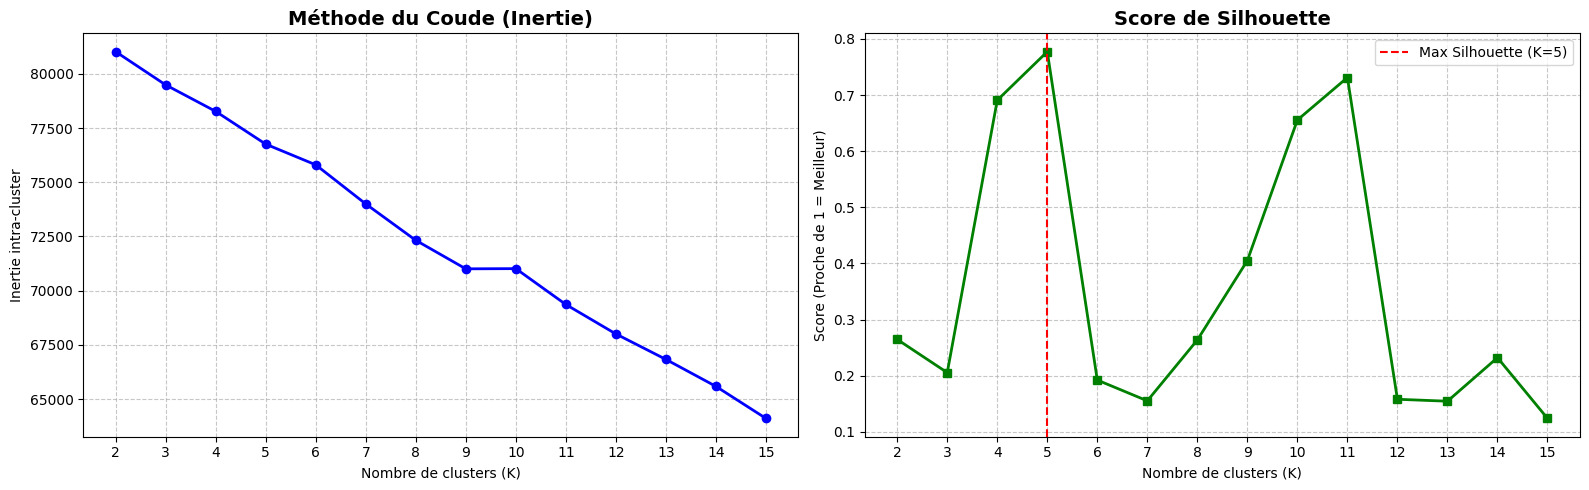


=> Mathématiquement, le K donnant la meilleure séparation pure est K = 5


In [17]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
from tqdm import tqdm

# Plage de K à tester (de 2 à 15 classes de styles potentiels)
K_range = range(2, 16)

inertia_values = []
silhouette_scores = []

print("Calcul des métriques pour trouver le K optimal (cela peut prendre quelques minutes)...")

for k in tqdm(K_range):
    # Initialisation du K-Means avec n_init=10 pour garantir la stabilité
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    cluster_labels_temp = kmeans.fit_predict(X_final_scaled)
    
    # Stockage de l'inertie (pour le Coude)
    inertia_values.append(kmeans.inertia_)
    
    # Stockage du score de silhouette
    score_sil = silhouette_score(X_final_scaled, cluster_labels_temp)
    silhouette_scores.append(score_sil)

# --- Affichage des résultats ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

# Graphique 1 : Méthode du Coude
ax1.plot(K_range, inertia_values, marker='o', linestyle='-', color='b', linewidth=2)
ax1.set_title("Méthode du Coude (Inertie)", fontsize=14, fontweight='bold')
ax1.set_xlabel("Nombre de clusters (K)")
ax1.set_ylabel("Inertie intra-cluster")
ax1.set_xticks(K_range)
ax1.grid(True, linestyle='--', alpha=0.7)

# Graphique 2 : Score de Silhouette
ax2.plot(K_range, silhouette_scores, marker='s', linestyle='-', color='g', linewidth=2)
ax2.set_title("Score de Silhouette", fontsize=14, fontweight='bold')
ax2.set_xlabel("Nombre de clusters (K)")
ax2.set_ylabel("Score (Proche de 1 = Meilleur)")
ax2.set_xticks(K_range)
ax2.grid(True, linestyle='--', alpha=0.7)

# Ligne rouge pour marquer le pic maximum de la silhouette
optimal_k_sil = K_range[silhouette_scores.index(max(silhouette_scores))]
ax2.axvline(x=optimal_k_sil, color='r', linestyle='--', label=f'Max Silhouette (K={optimal_k_sil})')
ax2.legend()

plt.tight_layout()
plt.show()

print(f"\n=> Mathématiquement, le K donnant la meilleure séparation pure est K = {optimal_k_sil}")

In [ ]:
from sklearn.cluster import KMeans

# Utilisation du K optimal trouvé automatiquement précédemment
# (si vous voulez le modifier manuellement, changez cette ligne)
k_choisi = optimal_k_sil
print(f"Lancement du K-Means avec K={k_choisi} (déterminé automatiquement par le score de Silhouette max) sur les features CNN...")

# Initialisation et exécution de l'algorithme
kmeans = KMeans(n_clusters=k_choisi, random_state=42, n_init=10)

# fit_predict regroupe les données et crée la fameuse variable manquante
cluster_labels = kmeans.fit_predict(X_final_scaled) 

print("Clustering terminé ! La variable 'cluster_labels' est prête.")

Lancement du K-Means avec K=5 sur les features CNN...
Clustering terminé ! La variable 'cluster_labels' est prête.


Liste recréée : 1645 images trouvées.
Préparation du modèle de recherche...


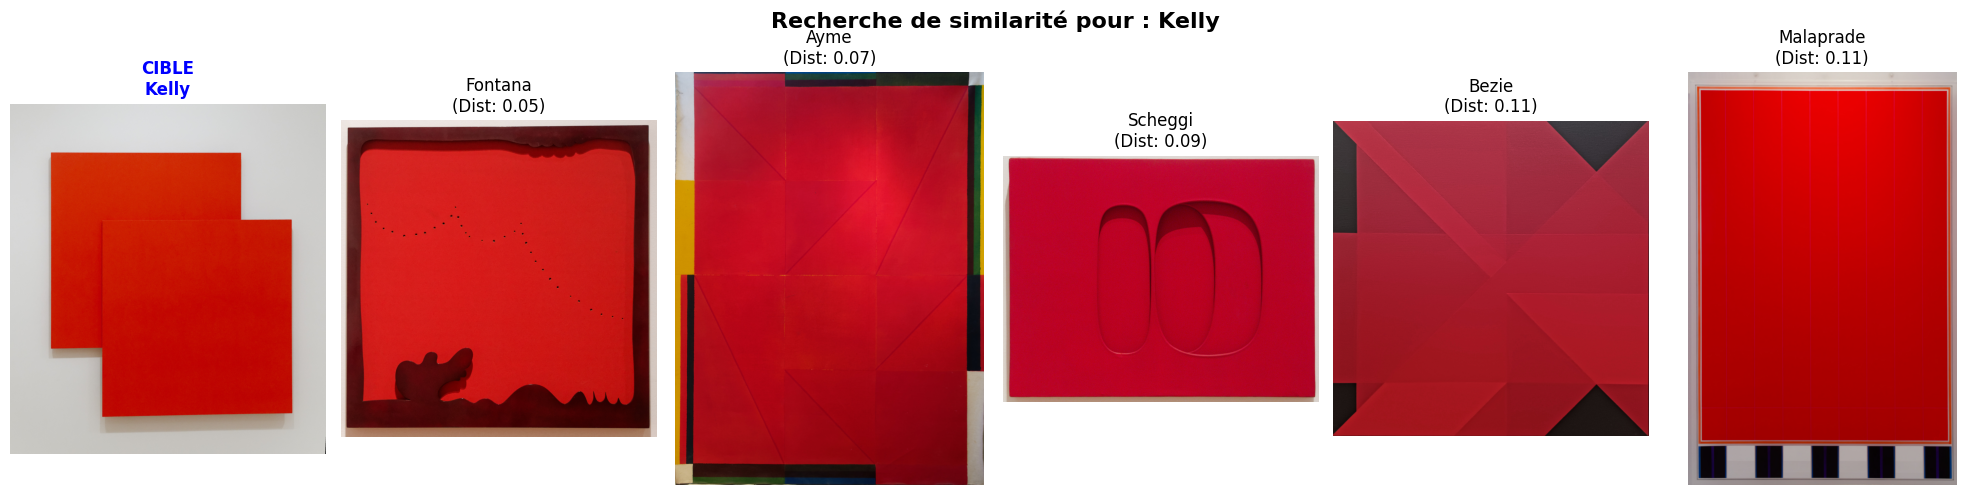

In [19]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from sklearn.neighbors import NearestNeighbors
import numpy as np
import random
import os

# --- 1. Recréation de la liste des noms d'images ---
# IMPORTANT : Remplacez par votre vrai chemin vers le dossier des images
dataset_dir = "abstrait-v3/" 
image_extensions = (".jpg", ".jpeg", ".png")

# On recrée la liste exactement comme lors de l'extraction initiale
image_names = [f for f in os.listdir(dataset_dir) if f.lower().endswith(image_extensions)]

print(f"Liste recréée : {len(image_names)} images trouvées.")

# Vérification de sécurité
if len(image_names) != X_final_scaled.shape[0]:
    print("ATTENTION : Le nombre d'images dans le dossier ne correspond pas à la taille de la matrice CNN !")

# --- 2. Entraînement du modèle de recherche de voisins ---
print("Préparation du modèle de recherche...")
nn_model = NearestNeighbors(n_neighbors=6, metric='cosine')
nn_model.fit(X_final_scaled) 

# --- 3. Sélection d'une image au hasard ---
idx_random = random.randint(0, len(image_names) - 1)
target_vector = X_final_scaled[idx_random].reshape(1, -1)
target_name = image_names[idx_random]

# --- 4. Recherche des 5 plus proches voisins ---
distances, indices = nn_model.kneighbors(target_vector)

# --- 5. Affichage avec Matplotlib ---
fig, axes = plt.subplots(1, 6, figsize=(20, 5))
fig.suptitle(f"Recherche de similarité pour : {target_name.split('_')[0].capitalize()}", fontsize=16, fontweight='bold')

for i, ax in enumerate(axes):
    voisin_idx = indices[0][i]
    voisin_name = image_names[voisin_idx]
    voisin_artiste = voisin_name.split('_')[0].capitalize()
    img_path = os.path.join(dataset_dir, voisin_name)
    
    try:
        # Chargement et affichage de l'image
        img = mpimg.imread(img_path)
        ax.imshow(img)
        
        # Titre (L'image cible en bleu, les voisins en noir)
        if i == 0:
            ax.set_title(f"CIBLE\n{voisin_artiste}", color='blue', fontweight='bold')
            ax.spines['bottom'].set_color('blue')
            ax.spines['top'].set_color('blue')
            ax.spines['left'].set_color('blue')
            ax.spines['right'].set_color('blue')
            ax.spines['bottom'].set_linewidth(3)
            ax.spines['top'].set_linewidth(3)
            ax.spines['left'].set_linewidth(3)
            ax.spines['right'].set_linewidth(3)
        else:
            dist_score = distances[0][i]
            ax.set_title(f"{voisin_artiste}\n(Dist: {dist_score:.2f})")
            
    except FileNotFoundError:
        ax.set_title(f"Image introuvable:\n{voisin_name}")
        
    ax.axis('off')

plt.tight_layout()
plt.show()

Calcul du t-SNE en 2D (cela peut prendre une minute)...


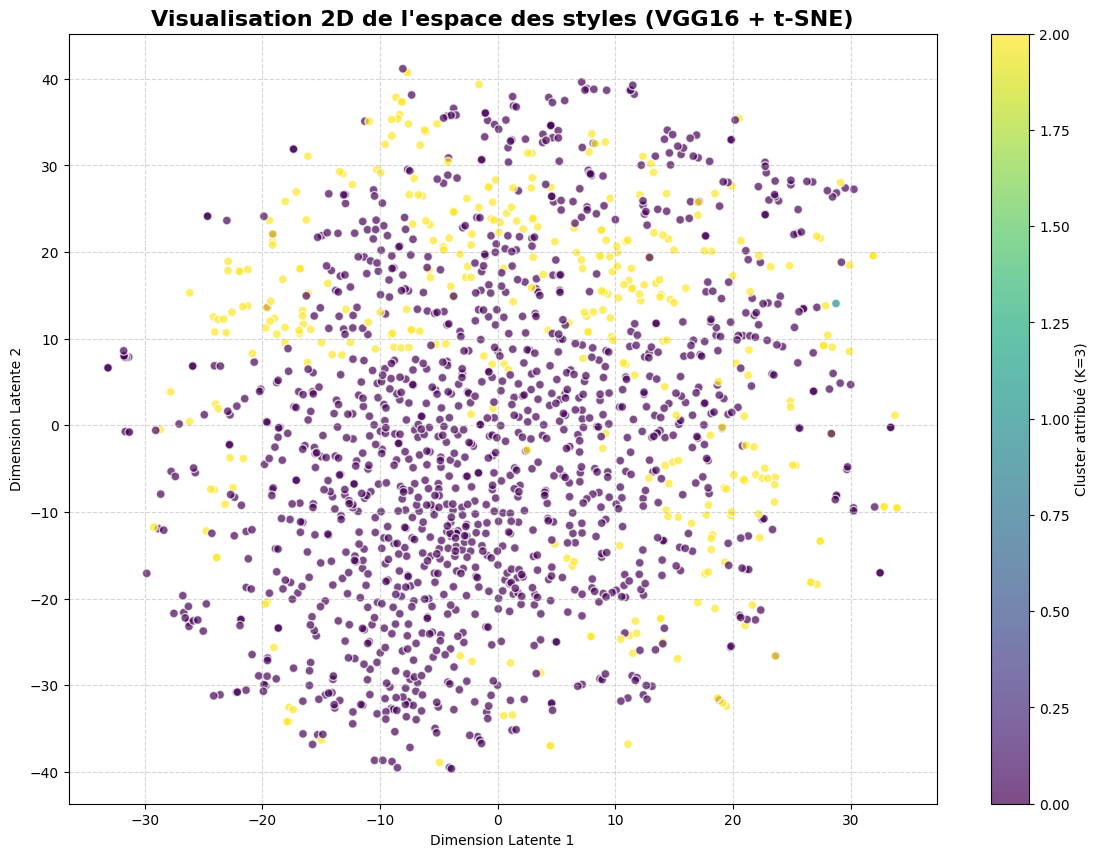

In [ ]:
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans

print("Calcul du t-SNE en 2D (cela peut prendre une minute)...")
# Réduction à 2 dimensions pour l'affichage
tsne = TSNE(n_components=2, perplexity=40, random_state=42)
X_tsne_2d = tsne.fit_transform(X_final_scaled)

# Recalcul rapide du K-Means avec le K optimal pour colorer les points
kmeans = KMeans(n_clusters=k_choisi, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(X_final_scaled)

# Affichage du graphique
plt.figure(figsize=(14, 10))
scatter = plt.scatter(
    X_tsne_2d[:, 0], 
    X_tsne_2d[:, 1], 
    c=cluster_labels, 
    cmap='viridis', # Palette de couleurs
    alpha=0.7, 
    edgecolors='w', 
    s=40
)

plt.title("Visualisation 2D de l'espace des styles (VGG16 + t-SNE)", fontsize=16, fontweight='bold')
plt.xlabel("Dimension Latente 1")
plt.ylabel("Dimension Latente 2")
plt.colorbar(scatter, label="Cluster attribué (K=3)")
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

Préparation du modèle de recherche et génération de la grille...


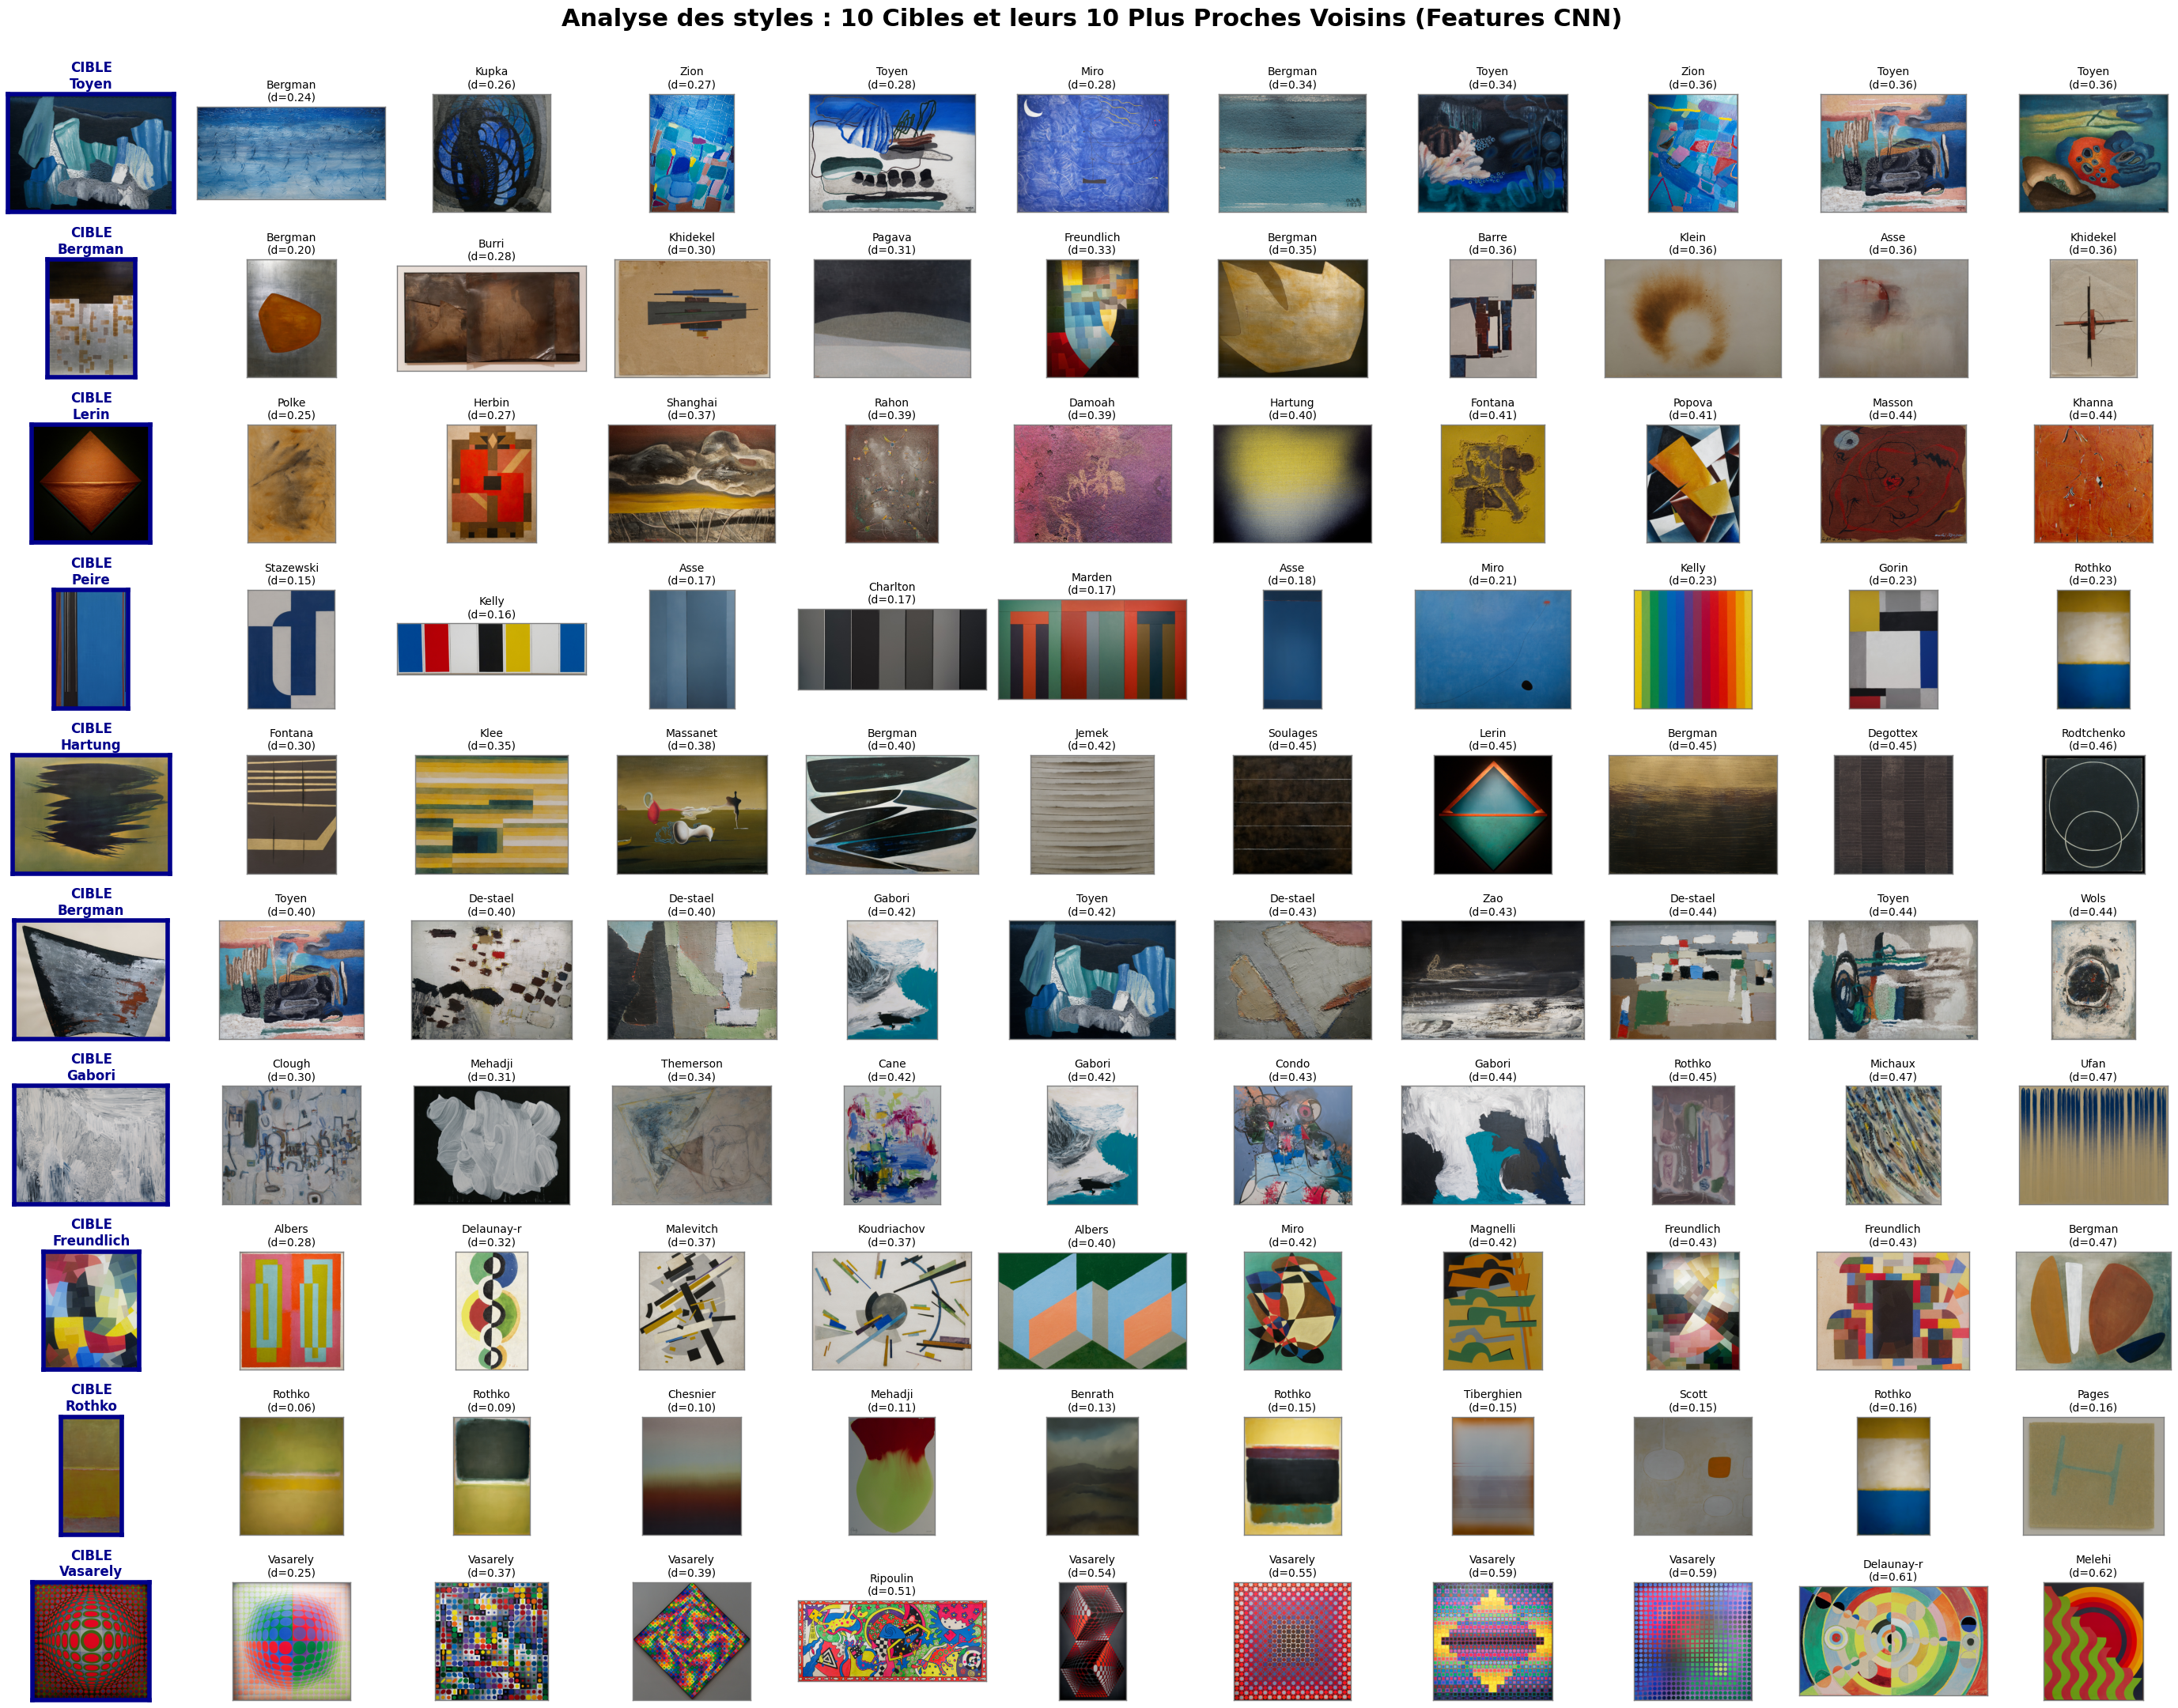

In [14]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from sklearn.neighbors import NearestNeighbors
import random
import os

print("Préparation du modèle de recherche et génération de la grille...")

# 1. Configuration du modèle (1 cible + 10 voisins = 11)
nn_model = NearestNeighbors(n_neighbors=11, metric='cosine')
nn_model.fit(X_final_scaled)

# 2. Sélection de 10 indices strictement au hasard
random_indices = random.sample(range(len(image_names)), 10)

# 3. Création d'une très grande figure pour accueillir 110 images
fig, axes = plt.subplots(10, 11, figsize=(28, 22))
fig.suptitle("Analyse des styles : 10 Cibles et leurs 10 Plus Proches Voisins (Features CNN)", fontsize=22, fontweight='bold', y=0.98)

# 4. Remplissage de la grille
for row, idx in enumerate(random_indices):
    target_vector = X_final_scaled[idx].reshape(1, -1)
    distances, indices = nn_model.kneighbors(target_vector)
    
    for col in range(11):
        ax = axes[row, col]
        voisin_idx = indices[0][col]
        voisin_name = image_names[voisin_idx]
        voisin_artiste = voisin_name.split('_')[0].capitalize()
        img_path = os.path.join(dataset_dir, voisin_name)
        
        try:
            img = mpimg.imread(img_path)
            ax.imshow(img)
            
            # Formatage spécifique pour la colonne CIBLE (colonne 0)
            if col == 0:
                ax.set_title(f"CIBLE\n{voisin_artiste}", color='darkblue', fontweight='bold', fontsize=12)
                for spine in ax.spines.values():
                    spine.set_color('darkblue')
                    spine.set_linewidth(4)
            # Formatage pour les VOISINS (colonnes 1 à 10)
            else:
                dist = distances[0][col]
                ax.set_title(f"{voisin_artiste}\n(d={dist:.2f})", fontsize=10)
                for spine in ax.spines.values():
                    spine.set_color('gray')
                    spine.set_linewidth(1)
                    
        except FileNotFoundError:
            ax.set_title("Image absente", fontsize=9)
            
        # Masquer les graduations des axes
        ax.set_xticks([])
        ax.set_yticks([])

plt.tight_layout()
# Ajustement pour que le grand titre ne chevauche pas les images
plt.subplots_adjust(top=0.93, hspace=0.4) 
plt.show()

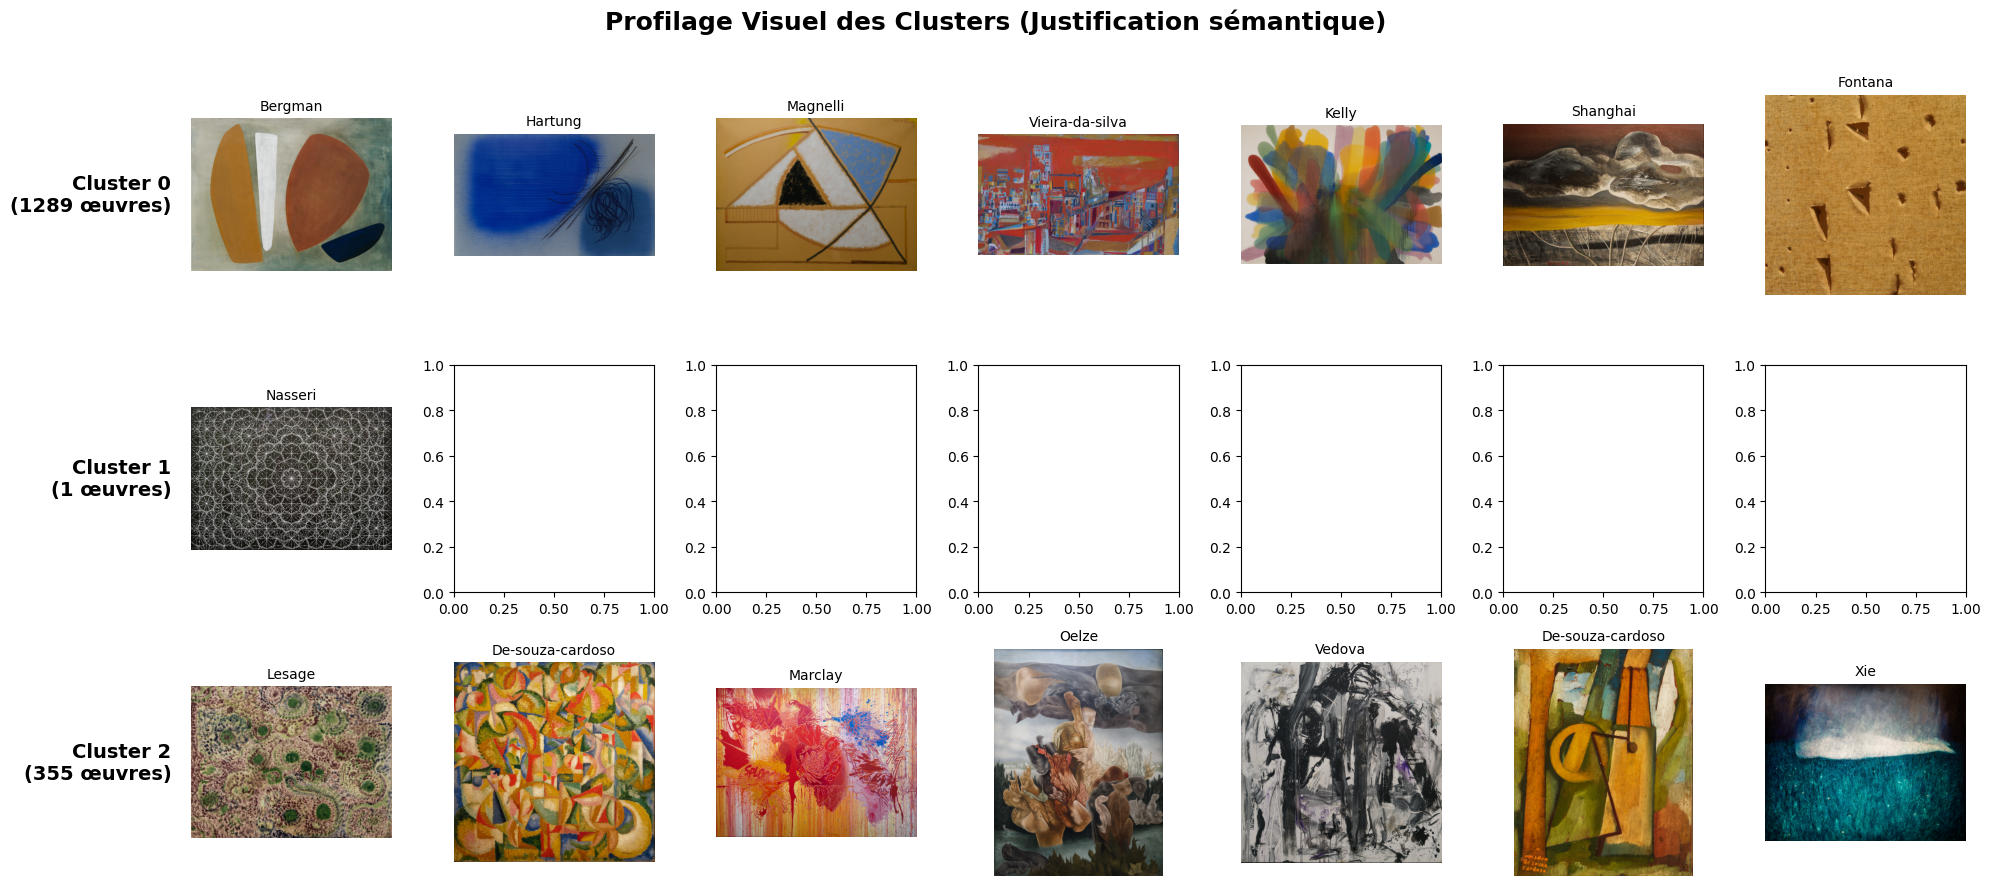

In [15]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import numpy as np
import os
import random

# Paramètres
# k_choisi correspond au nombre de clusters que vous avez utilisé (ex: 3)
nb_exemples_par_cluster = 7 

fig, axes = plt.subplots(k_choisi, nb_exemples_par_cluster, figsize=(20, 3 * k_choisi))
fig.suptitle("Profilage Visuel des Clusters (Justification sémantique)", fontsize=18, fontweight='bold', y=0.98)

for cluster_id in range(k_choisi):
    # Trouver tous les indices des images appartenant à ce cluster
    indices_cluster = np.where(cluster_labels == cluster_id)[0]
    
    # Prendre un échantillon au hasard (ou toutes si le cluster est tout petit)
    nb_samples = min(nb_exemples_par_cluster, len(indices_cluster))
    echantillon_indices = random.sample(list(indices_cluster), nb_samples)
    
    for col, idx in enumerate(echantillon_indices):
        ax = axes[cluster_id, col]
        nom_image = image_names[idx]
        artiste = nom_image.split('_')[0].capitalize()
        img_path = os.path.join(dataset_dir, nom_image)
        
        try:
            img = mpimg.imread(img_path)
            ax.imshow(img)
            ax.set_title(f"{artiste}", fontsize=10)
        except FileNotFoundError:
            ax.set_title("Introuvable", fontsize=10)
            
        ax.axis('off')
        
    # Ajouter un label de ligne pour identifier le cluster
    axes[cluster_id, 0].text(-0.1, 0.5, f"Cluster {cluster_id}\n({len(indices_cluster)} œuvres)", 
                             transform=axes[cluster_id, 0].transAxes, 
                             fontsize=14, fontweight='bold', va='center', ha='right')

plt.tight_layout()
plt.subplots_adjust(top=0.9)
plt.show()

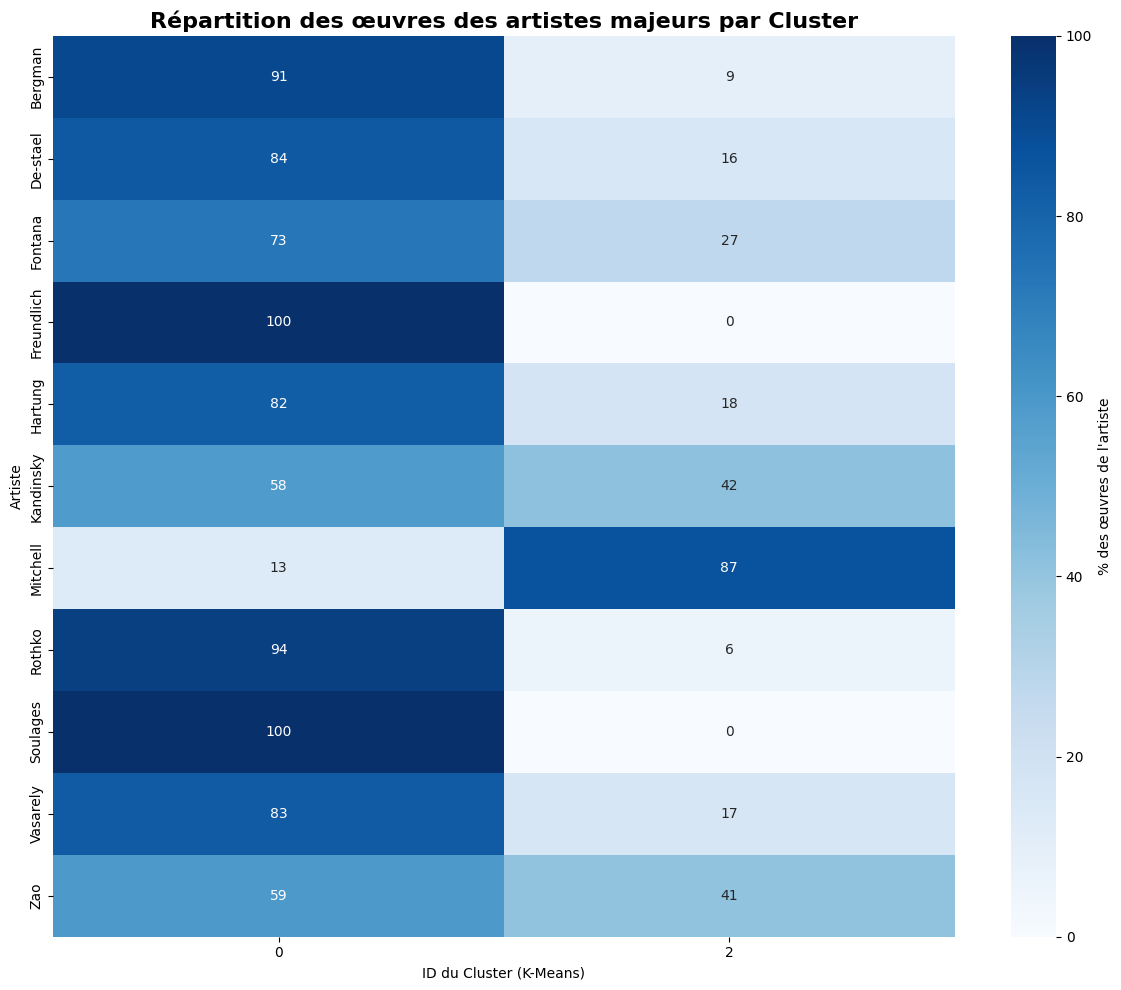

In [16]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Création d'un DataFrame global
artistes = [nom.split('_')[0].capitalize() for nom in image_names]
df_results = pd.DataFrame({
    'Artiste': artistes,
    'Cluster': cluster_labels
})

# 2. Filtrer pour ne garder que les artistes "majeurs" 
# (ceux qui ont au moins 20 œuvres, pour que la statistique ait du sens)
seuil_oeuvres = 20
comptage_artistes = df_results['Artiste'].value_counts()
artistes_majeurs = comptage_artistes[comptage_artistes >= seuil_oeuvres].index

df_majeurs = df_results[df_results['Artiste'].isin(artistes_majeurs)]

# 3. Tableau croisé : Combien d'œuvres de l'artiste X sont dans le cluster Y ?
crosstab = pd.crosstab(df_majeurs['Artiste'], df_majeurs['Cluster'])

# Transformation en pourcentages (chaque ligne = 100% de l'oeuvre de l'artiste)
crosstab_pct = crosstab.div(crosstab.sum(axis=1), axis=0) * 100

# 4. Affichage de la Heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(crosstab_pct, annot=True, fmt=".0f", cmap="Blues", cbar_kws={'label': '% des œuvres de l\'artiste'})

plt.title("Répartition des œuvres des artistes majeurs par Cluster", fontsize=16, fontweight='bold')
plt.xlabel("ID du Cluster (K-Means)")
plt.ylabel("Artiste")
plt.tight_layout()
plt.show()